In [28]:
import pandas as pd
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
corpus = pd.read_csv('/content/Corpus_Preprocessing.csv')
corpus.head()

,Unnamed: 0,fecha,titulo,cuerpo,url,categoria,categoria_grupo,texto_tfidf
0,580,2025-08-26 13:31:46-05:00,YouTube hizo inesperado movimiento con intelig...,La plataforma de entretenimiento YouTube cuent...,https://www.semana.com//tecnologia/articulo/yo...,tecnologia,tecnologia_ciencia,plataforma entretenimiento youtube contar mill...
1,581,2025-08-26 16:39:02-05:00,Apple reveló la fecha de lanzamiento del iPhon...,Apple celebrará un nuevo evento de presentació...,https://www.semana.com//tecnologia/articulo/ap...,tecnologia,tecnologia_ciencia,apple celebrar evento presentacion producto se...
2,582,2025-08-21 19:13:31-05:00,La estrella más lejana conocida puede no serlo...,"Eärendel, un objeto descubierto en 2022 con el...",https://www.semana.com//tecnologia/articulo/la...,tecnologia,tecnologia_ciencia,rendel objeto descubierto telescopio espacial ...
3,583,2025-08-08 20:07:54-05:00,Por primera vez en la historia: investigadores...,Un equipo de especialistas en ciberseguridad r...,https://www.semana.com//tecnologia/articulo/po...,tecnologia,tecnologia_ciencia,equipo especialista ciberseguridad revelo meto...
4,584,2025-08-28 14:57:58-05:00,No solo es la inteligencia artificial: esta es...,"Para muchos ha resultado sorprendente cómo, en...",https://www.semana.com//tecnologia/articulo/no...,tecnologia,tecnologia_ciencia,resultar sorprendente ano inteligencia artific...


### Metodología de Análisis de Sentimiento (modelo BETO – 5+1 clases)

Para clasificar el sentimiento en textos extensos, como lo son las noticas, empleamos el checkpoint en español  
**`ignacio-ave/beto-sentiment-analysis-spanish`**, basado en **BETO** (BERT entrenado para español) y **afinado para análisis de sentimiento**.  
Este modelo produce **clases ordinales** de polaridad:

- **VERY NEGATIVE**, **NEGATIVE**, **NEUTRAL**, **POSITIVE**, **VERY POSITIVE**  
- y una clase de reserva **UNDEFINED** cuando el texto no encaja en las anteriores.

**Ventajas del enfoque preentrenado.** No necesitamos construir embeddings manualmente: el modelo realiza **tokenización sub-palabra** y genera **representaciones contextuales** internamente, lo que ofrece mejor precisión que enfoques de bolsa de palabras o embeddings estáticos.

**Textos largos (límite de 512 tokens).** Para no perder información en noticias largas, usamos una estrategia de **ventanas deslizantes** (*windowing*): dividimos cada documento en *chunks* de hasta **512 tokens** con **solapamiento** (*stride*). Cada chunk se procesa en **lotes (batch)** con **padding dinámico** en GPU. Para combinar las predicciones de un mismo documento, **promediamos los *logits*** de todos sus chunks y luego aplicamos *softmax*, obteniendo una probabilidad por clase para el documento completo. Esta agregación es **más estable** que promediar probabilidades directamente.

**Salida y columnas en el DataFrame.** Para cada noticia incorporamos:
1. `sentimiento_5clases`: etiqueta ordinal en {VERY NEGATIVE, NEGATIVE, NEUTRAL, POSITIVE, VERY POSITIVE} (o **UNDEFINED** cuando ocurra).
2. `score_5clases`: probabilidad asignada por el modelo a la clase elegida (tras la agregación por chunks).


**Detalles de implementación.** Usamos **modelo y tokenizer del mismo repo** para evitar desalineaciones, ejecución **en GPU** con *batching* y **padding dinámico**, y control de solapamiento (*stride*) para balancear cobertura contextual y eficiencia computacional. Esta configuración prioriza **robustez reproducible** y **escalabilidad** sobre corpus noticiosos.




In [10]:
import torch, numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "enable_flash_sdp"):
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)

MODEL = "ignacio-ave/beto-sentiment-analysis-spanish"
TOKENIZER = MODEL
BATCH_SIZE = 32
MAX_LEN = 512
STRIDE   = 128
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

texts = corpus["texto_tfidf"].fillna("").astype(str).tolist()

tok = AutoTokenizer.from_pretrained(TOKENIZER, use_fast=True, model_max_length=MAX_LEN)
tok.padding_side = "right"
tok.truncation_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token if tok.eos_token is not None else tok.cls_token

mdl = AutoModelForSequenceClassification.from_pretrained(MODEL)
mdl.config.pad_token_id = tok.pad_token_id
mdl = mdl.to(DEVICE).eval()

id2label = mdl.config.id2label
num_labels = mdl.config.num_labels

mini = tok(["hola mundo"], return_tensors="pt", padding=True, truncation=True, max_length=64)
with torch.no_grad():
    _ = mdl(**{k: v.to(DEVICE) for k,v in mini.items()})


enc = tok(texts,
    truncation=True, max_length=MAX_LEN, stride=STRIDE,
    return_overflowing_tokens=True, return_tensors=None)
sample_map = enc.pop("overflow_to_sample_mapping")

class ChunksDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, sample_map):
        self.encodings, self.sample_map = encodings, sample_map
    def __len__(self): return len(self.sample_map)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["sample_idx"] = self.sample_map[idx]
        return item

ds = ChunksDataset(enc, sample_map)
collator = DataCollatorWithPadding(tokenizer=tok)

def collate_fn(batch):
    sample_idx = torch.tensor([b["sample_idx"] for b in batch], dtype=torch.long)
    model_inputs = {k: [b[k] for b in batch] for k in batch[0] if k != "sample_idx"}
    model_inputs = collator(model_inputs)
    model_inputs["sample_idx"] = sample_idx
    return model_inputs

dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

sum_logits = [np.zeros((num_labels,), dtype=np.float32) for _ in range(len(texts))]
count_chunks = [0 for _ in range(len(texts))]

with torch.no_grad():
    for batch in dl:
        sample_idx = batch.pop("sample_idx").cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = mdl(**batch)
        logits = out.logits.detach().cpu().numpy()
        for i, doc_id in enumerate(sample_idx):
            sum_logits[doc_id] += logits[i]
            count_chunks[doc_id] += 1

labels, scores = [], []
for doc_id in range(len(texts)):
    mean_logits = sum_logits[doc_id] / max(count_chunks[doc_id], 1)
    probs = np.exp(mean_logits - mean_logits.max()); probs /= probs.sum()
    lid = int(np.argmax(probs))
    labels.append(id2label[lid])
    scores.append(float(probs[lid]))

corpus["sentimiento"] = labels
corpus["score"] = scores

In [20]:
corpus.head()

,Unnamed: 0,fecha,titulo,cuerpo,url,categoria,categoria_grupo,texto_tfidf,sentimiento,score
0,580,2025-08-26 13:31:46-05:00,YouTube hizo inesperado movimiento con intelig...,La plataforma de entretenimiento YouTube cuent...,https://www.semana.com//tecnologia/articulo/yo...,tecnologia,tecnologia_ciencia,plataforma entretenimiento youtube contar mill...,VERY POSITIVE,0.489073
1,581,2025-08-26 16:39:02-05:00,Apple reveló la fecha de lanzamiento del iPhon...,Apple celebrará un nuevo evento de presentació...,https://www.semana.com//tecnologia/articulo/ap...,tecnologia,tecnologia_ciencia,apple celebrar evento presentacion producto se...,POSITIVE,0.856817
2,582,2025-08-21 19:13:31-05:00,La estrella más lejana conocida puede no serlo...,"Eärendel, un objeto descubierto en 2022 con el...",https://www.semana.com//tecnologia/articulo/la...,tecnologia,tecnologia_ciencia,rendel objeto descubierto telescopio espacial ...,NEGATIVE,0.602729
3,583,2025-08-08 20:07:54-05:00,Por primera vez en la historia: investigadores...,Un equipo de especialistas en ciberseguridad r...,https://www.semana.com//tecnologia/articulo/po...,tecnologia,tecnologia_ciencia,equipo especialista ciberseguridad revelo meto...,VERY NEGATIVE,0.715093
4,584,2025-08-28 14:57:58-05:00,No solo es la inteligencia artificial: esta es...,"Para muchos ha resultado sorprendente cómo, en...",https://www.semana.com//tecnologia/articulo/no...,tecnologia,tecnologia_ciencia,resultar sorprendente ano inteligencia artific...,VERY POSITIVE,0.640022


In [15]:
corpus.to_csv('Corpus_sentimiento.csv')

## Analisis de los sentimientos clasificados

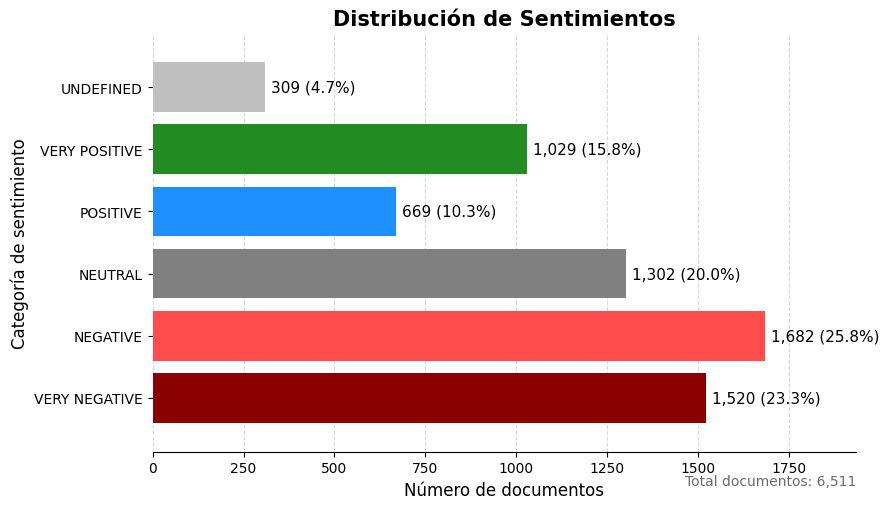

In [19]:
import matplotlib.pyplot as plt

def plot_sentiment_bars(df, col="sentimiento"):
    counts = df[col].value_counts(dropna=False)
    total = int(counts.sum())
    preferred_order = ["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE", "UNDEFINED"]
    ordered_index = [c for c in preferred_order if c in counts.index] + \
                    [c for c in counts.index if c not in preferred_order]
    counts = counts.reindex(ordered_index)

    pct = (counts / total * 100).round(1)

    color_map = {
        "VERY NEGATIVE": "#8B0000",
        "NEGATIVE": "#FF4C4C",
        "NEUTRAL": "#808080",
        "POSITIVE": "#1E90FF",
        "VERY POSITIVE": "#228B22",
        "UNDEFINED": "#C0C0C0"}
    colors = [color_map.get(cat, "#4682B4") for cat in counts.index]

    fig, ax = plt.subplots(figsize=(9, 5.2))
    bars = ax.barh(counts.index, counts.values, color=colors)

    for bar, c, p in zip(bars, counts.values, pct.values):
        w = bar.get_width()
        ax.text(
            w + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{c:,.0f} ({p:.1f}%)",
            va="center", ha="left", fontsize=11)

    ax.set_title("Distribución de Sentimientos", fontsize=15, fontweight="bold")
    ax.set_xlabel("Número de documentos", fontsize=12)
    ax.set_ylabel("Categoría de sentimiento", fontsize=12)

    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_xlim(0, max(counts.values) * 1.15)
    ax.margins(y=0.08)
    ax.text(
        1.0, -0.08,
        f"Total documentos: {total:,}",
        transform=ax.transAxes, fontsize=10, ha="right", color="dimgray")
    plt.tight_layout()
    plt.show()

plot_sentiment_bars(corpus, col="sentimiento")

### Interpretación preliminar de la distribución de sentimientos

La mayor parte de los documentos analizados exhibe una carga **negativa**:  
- **NEGATIVE (25.8%)** y **VERY NEGATIVE (23.3%)** concentran casi **la mitad de las observaciones**.  
- En contraste, los documentos con valoración **positiva** (POSITIVE + VERY POSITIVE) apenas suman **26.1%**.  
- El segmento **NEUTRAL (20%)** también tiene un peso considerable, reflejando una proporción relevante de textos sin polaridad marcada.  
- Finalmente, un **4.7%** de los casos quedó en **UNDEFINED**, probablemente asociado a textos ambiguos o con bajo contenido emocional.

En conjunto, esta distribución sugiere que el corpus de noticias tiende a resaltar **aspectos negativos** más que positivos, aunque también hay una fracción no despreciable de contenidos neutrales y positivos.  



/tmp/ipython-input-2135423997.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


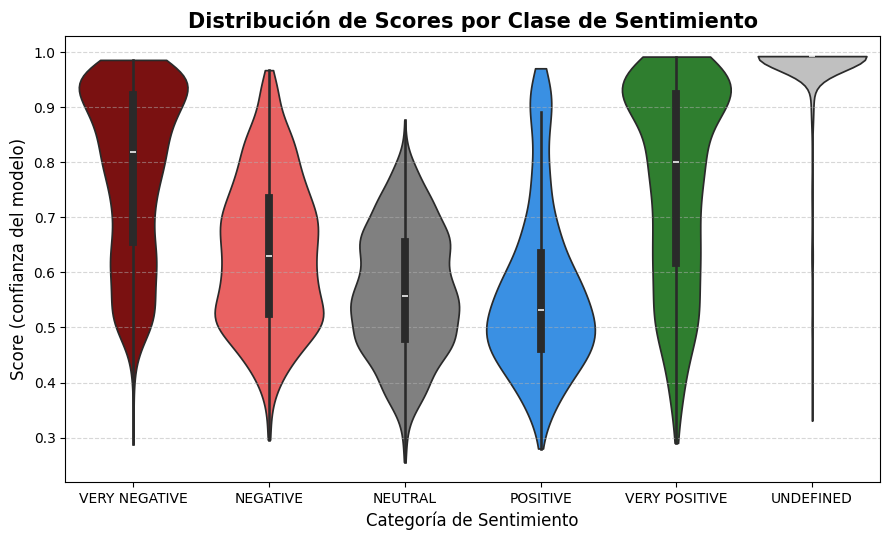

In [31]:
import seaborn as sns

if "sentimiento" in corpus.columns and "score" in corpus.columns:
    plt.figure(figsize=(9, 5.5))
    sns.violinplot(
        data=corpus,
        x="sentimiento",
        y="score",
        order=["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE", "UNDEFINED"],
        palette={
            "VERY NEGATIVE": "#8B0000",
            "NEGATIVE": "#FF4C4C",
            "NEUTRAL": "#808080",
            "POSITIVE": "#1E90FF",
            "VERY POSITIVE": "#228B22",
            "UNDEFINED": "#C0C0C0"
        },
        inner="box",
        cut=0)
    plt.title("Distribución de Scores por Clase de Sentimiento", fontsize=15, fontweight="bold")
    plt.xlabel("Categoría de Sentimiento", fontsize=12)
    plt.ylabel("Score (confianza del modelo)", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("El DataFrame no contiene las columnas 'sentimiento' y 'score'.")

### Interpretación del violin plot de scores

El gráfico muestra cómo varía la **confianza del modelo** (`score`) en cada clase de sentimiento:

1. **Clases extremas (VERY NEGATIVE y VERY POSITIVE)**  
   - Presentan distribuciones muy concentradas en valores altos (≈0.9–1.0).  
   - Esto indica que cuando el modelo asigna una polaridad muy marcada, lo hace con gran seguridad.  
   - La mediana es claramente alta, y la dispersión relativamente baja.

2. **Clases intermedias (NEGATIVE y POSITIVE)**  
   - Los scores son más dispersos (≈0.4–0.8).  
   - El modelo reconoce estas categorías, pero con menor confianza que en los extremos.  
   - Esto refleja que algunos textos cercanos a la frontera entre positivo/negativo se asignan con incertidumbre.

3. **Clase NEUTRAL**  
   - La distribución está centrada en valores medios (≈0.5–0.7).  
   - Confirma que el modelo tiende a ser **menos categórico** con noticias neutras, lo que es coherente con la naturaleza ambigua de este sentimiento.  
   - Es la clase con mayor variabilidad en confianza.

4. **Clase UNDEFINED**  
   - Llama la atención que sus scores aparecen en el rango más alto (≈0.9–1.0).  
   - Esto sugiere que el modelo es **muy seguro cuando detecta casos no clasificables**, probablemente porque el texto no contiene señales afectivas claras.  
   - En la práctica, conviene revisar cómo manejar esta categoría (excluirla, o tratarla como “indefinida”).

---

### Conclusión
El modelo muestra un patrón consistente:  
- **Alta seguridad en los extremos** (very negative / very positive).  
- **Confianza moderada en clases intermedias** (negative / positive).  
- **Neutralidad menos definida**, con mayor dispersión de scores.  
- **Undefined** funciona como una clase “segura”, pero que representa ambigüedad semántica.


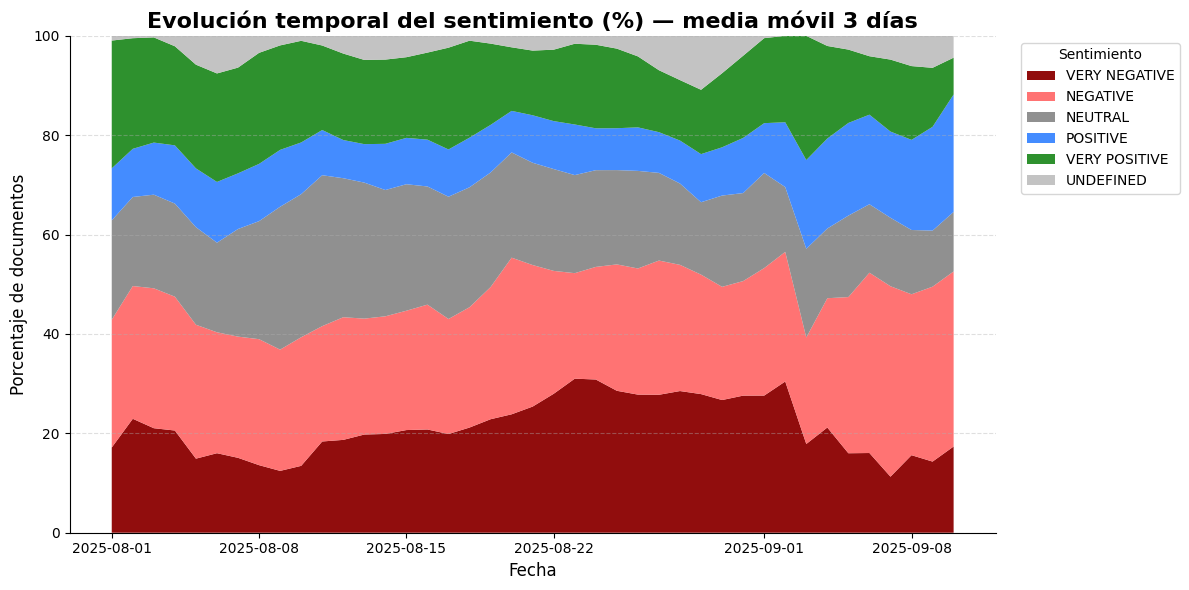

In [44]:

fecha_col = "fecha"
sent_col  = "sentimiento"
window = 3
min_docs = 20

corpus[fecha_col] = pd.to_datetime(corpus[fecha_col], utc=True, errors="coerce")
df = corpus.dropna(subset=[fecha_col]).copy()
df["dia"] = df[fecha_col].dt.floor("D")

daily_counts = (
    df.groupby(["dia", sent_col])
      .size().unstack(fill_value=0)
      .sort_index())
all_days = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D", tz="UTC")
daily_counts = daily_counts.reindex(all_days, fill_value=0)
daily_counts.index.name = "dia"
daily_tot = daily_counts.sum(axis=1)
daily_pct = daily_counts.div(daily_tot.replace(0, np.nan), axis=0) * 100
daily_pct_filtered = daily_pct.where(daily_tot >= min_docs)
daily_pct_smooth = daily_pct_filtered.rolling(window=window, min_periods=1).mean()

order = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"]
         if c in daily_pct_smooth.columns]
color_map = {
    "VERY NEGATIVE": "#8B0000",
    "NEGATIVE":      "#FF6B6B",
    "NEUTRAL":       "#8A8A8A",
    "POSITIVE":      "#3A86FF",
    "VERY POSITIVE": "#228B22",
    "UNDEFINED":     "#C0C0C0"}

colors = [color_map[c] for c in order]

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(daily_pct_smooth.index.to_pydatetime(),
             *[daily_pct_smooth[c].values for c in order],
             labels=order, colors=colors, alpha=0.95)

ax.set_title("Evolución temporal del sentimiento (%) — media móvil {} días".format(window),
             fontsize=16, fontweight="bold")
ax.set_ylabel("Porcentaje de documentos", fontsize=12)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

El gráfico refleja que, aunque existe cierta oscilación día a día, el tono predominante del corpus es negativo, con apariciones relevantes de neutralidad y una presencia positiva más limitada. El suavizado de 3 días ayuda a ver que estas proporciones no responden a picos aislados, sino a una tendencia estructural en la distribución del sentimiento.

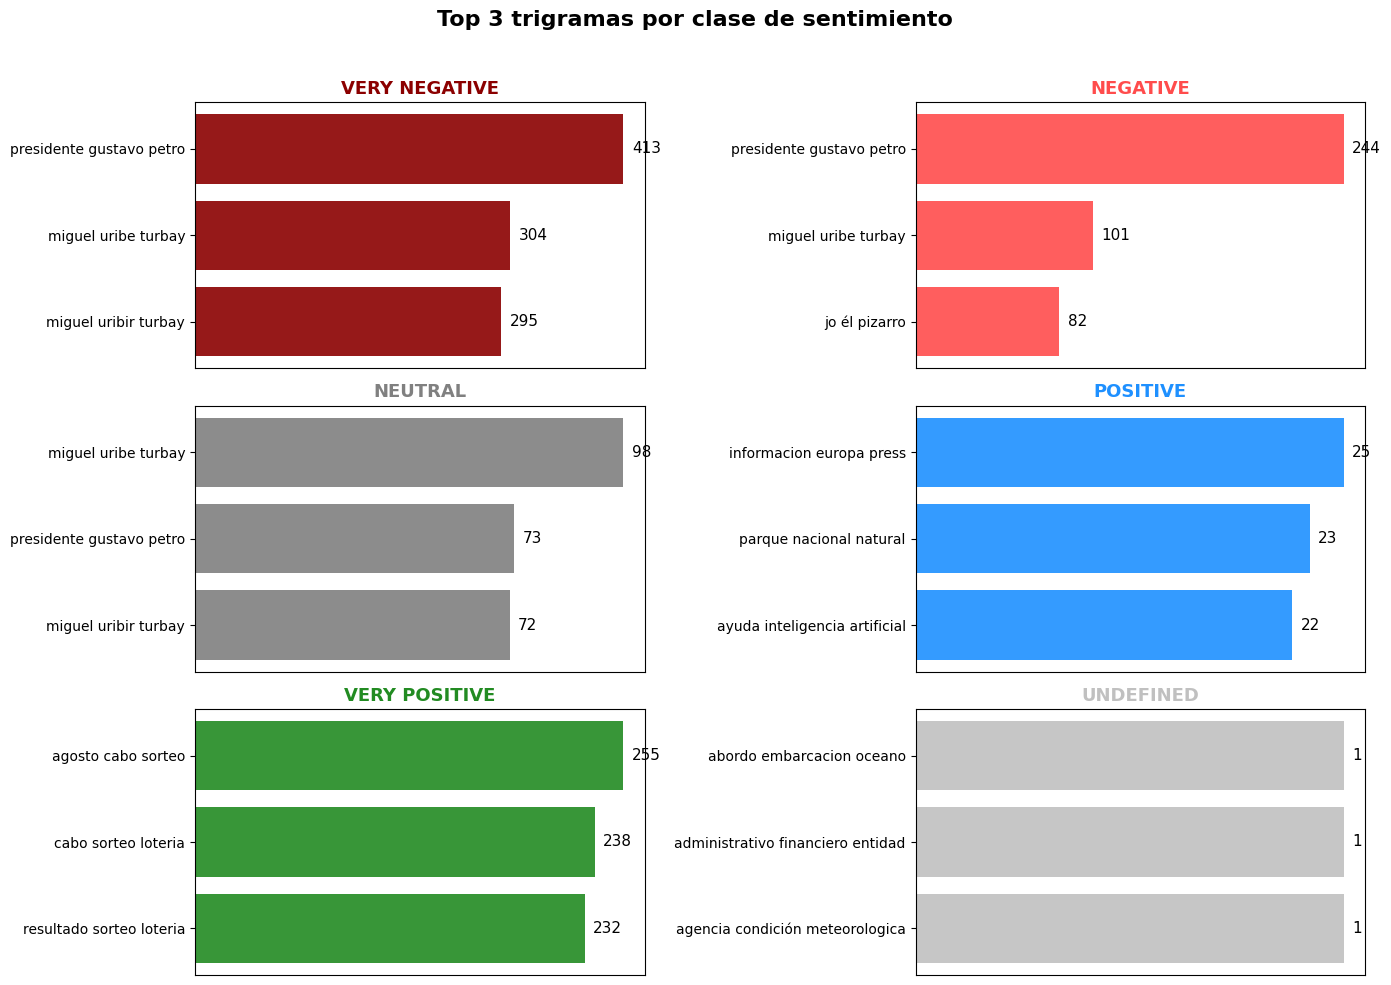

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

corpus["texto"] = corpus["texto_tfidf"].astype(str)
clases = corpus["sentimiento"].unique()
clases = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"] if c in clases]


color_map = {
    "VERY NEGATIVE": "#8B0000",
    "NEGATIVE": "#FF4C4C",
    "NEUTRAL": "#808080",
    "POSITIVE": "#1E90FF",
    "VERY POSITIVE": "#228B22",
    "UNDEFINED": "#C0C0C0"}

def top_ngrams(texts, n=3, ngram_range=(3,3)):
    vec = CountVectorizer(ngram_range=ngram_range)
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    freq = sorted(zip(vocab, counts), key=lambda x: x[1], reverse=True)[:n]
    return freq

clases = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"]
          if c in corpus["sentimiento"].unique()]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, clase in enumerate(clases):
    texts = corpus.loc[corpus["sentimiento"] == clase, "texto"]
    top3 = top_ngrams(texts, n=3)

    ax = axes[i]
    if top3:
        ngrams, freqs = zip(*top3)
        ax.barh(ngrams, freqs, color=color_map.get(clase, "#1f77b4"), alpha=0.9)
        ax.set_title(clase, fontsize=13, fontweight="bold", color=color_map.get(clase, "black"))
        ax.invert_yaxis()
        for j, v in enumerate(freqs):
            ax.text(v + max(freqs)*0.02, j, str(v), va="center", fontsize=11, color="black")
        ax.set_xticks([])
    else:
        ax.axis("off")

for j in range(len(clases), 6):
    fig.delaxes(axes[j])

plt.suptitle("Top 3 trigramas por clase de sentimiento", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##  Interpretación de trigramas por sentimiento

1. **VERY NEGATIVE (Rojo oscuro)**  
   - Predominan los trigramas *“presidente gustavo petro”* y *“miguel uribe turbay”*.  
   - Esto indica que la narrativa muy negativa está fuertemente vinculada a la **crítica política**, con énfasis en figuras de alto perfil.  
   - Sugiere un discurso polarizado y confrontacional.
   - Tambien se habla de la muerte del pre candidato Miguel Uribe

2. **NEGATIVE (Rojo claro)**  
   - Destacan *“presidente gustavo petro”* y *“miguel uribe turbay”*, pero aparece también *“jo él pizarro”*.  
   - Refleja la extensión del sentimiento negativo hacia otros actores políticos.  
   - Reafirma que el eje central de lo negativo es el **debate político nacional**.

3. **NEUTRAL (Gris)**  
   - Los trigramas más frecuentes siguen siendo *“miguel uribe turbay”* y *“presidente gustavo petro”*.  
   - La diferencia es que aquí los nombres aparecen en un **tono descriptivo/informativo** más que crítico.  
   - El sentimiento neutro cumple el rol de narrar hechos sin carga emocional fuerte.

4. **POSITIVE (Azul)**  
   - Se destacan *“informacion europa press”*, *“parque nacional natural”* y *“ayuda inteligencia artificial”*.  
   - Este grupo refleja un sentimiento positivo orientado a **temas tecnológicos, ambientales e internacionales**.  
   - Muestra un contraste claro frente al predominio político en los negativos.

5. **VERY POSITIVE (Verde)**  
   - Aparecen trigramas como *“agosto cabo sorteo”*, *“cabo sorteo loteria”* y *“resultado sorteo loteria”*.  
   - El tono muy positivo se vincula principalmente a **eventos de lotería o premios**.  
   - Refleja una narrativa de celebración y expectativas favorables.

6. **UNDEFINED (Gris claro)**  
   - Los trigramas (*“abordo embarcacion oceano”*, *“administrativo financiero entidad”*, *“agencia condición meteorologica”*) aparecen solo una vez.  
   - Esto indica que esta categoría es marginal y no tiene patrones representativos claros.  